In [1]:
import pandas as pd

# Load train & test dataset
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


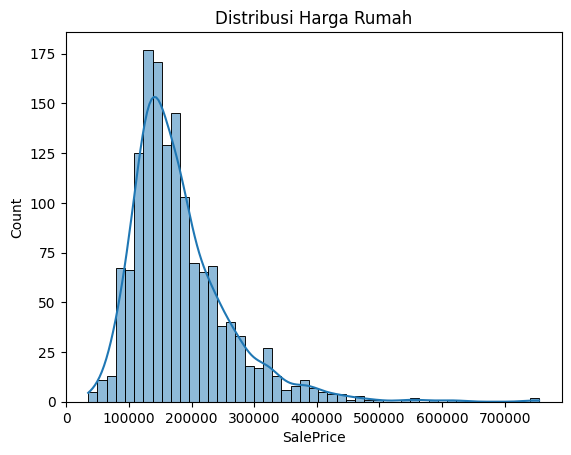

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi harga rumah
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribusi Harga Rumah")
plt.show()

# Ambil hanya kolom numerik
numeric_features = train.select_dtypes(include=[int, float])

# Korelasi fitur numerik dengan SalePrice
corr = numeric_features.corr()["SalePrice"].sort_values(ascending=False)
print(corr.head(10))

In [3]:
# Cek nama kolom yang tersedia
print(train.columns.tolist())

# Contoh fitur baru
train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
test["HouseAge"] = test["YrSold"] - test["YearBuilt"]

train["TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]
test["TotalSF"] = test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"]

# Pilih beberapa kolom kategorikal yang memang ada
categorical_cols = ["MSZoning","Street","Neighborhood"]  # pastikan ada di hasil print

# Encode hanya kolom yang ada
train = pd.get_dummies(train, columns=[col for col in categorical_cols if col in train.columns], drop_first=True)
test = pd.get_dummies(test, columns=[col for col in categorical_cols if col in test.columns], drop_first=True)

print("Train shape after encoding:", train.shape)
print("Test shape after encoding:", test.shape)

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

Jumlah fitur: 39
Explained variance ratio total: 0.8442859142226358


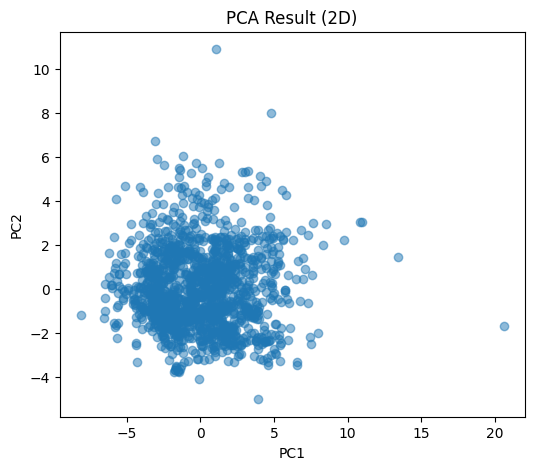

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ambil hanya fitur numerik (drop target SalePrice)
X = train.drop("SalePrice", axis=1).select_dtypes(include=[int,float]).fillna(0)

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sesuaikan jumlah komponen PCA (misalnya 20, atau maksimal jumlah fitur)
n_features = X_scaled.shape[1]
pca = PCA(n_components=min(20, n_features), random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Jumlah fitur:", n_features)
print("Explained variance ratio total:", sum(pca.explained_variance_ratio_))

# Visualisasi 2 komponen pertama
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA Result (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

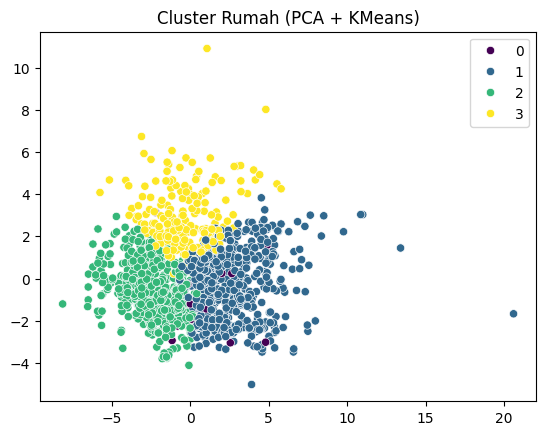

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)
train["Cluster"] = clusters

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="viridis")
plt.title("Cluster Rumah (PCA + KMeans)")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

# Pisahkan data
X = train.drop("SalePrice", axis=1).select_dtypes(include=[int,float]).fillna(0)
y = train["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

# XGBoost
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))

Random Forest RMSE: 30563.593595052822
XGBoost RMSE: 26842.89105144973
